In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

os.chdir(r'C:\Users\aruna\Desktop\Work\MLDAY1')

df=pd.read_csv('train.csv')
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(15))

(1460, 81)
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
dtype: int64


In [2]:
# drop high missing columns
df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 
                 'Fence', 'FireplaceQu'], inplace=True)

# drop useless columns
df.drop(columns=['Id'], inplace=True)

# fill garage columns with mode
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in garage_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# fill GarageYrBlt with median
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())

# fill LotFrontage with median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# fill basement columns with mode
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in bsmt_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# fill MasVnrType and MasVnrArea
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

# fill Electrical
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print(df.isnull().sum().sum())  # should be 0
print(df.shape)

0
(1460, 75)


In [3]:
df_numeric = df.select_dtypes(include=[np.number])
print(df_numeric.shape)
print(df_numeric.columns.tolist())

(1460, 37)
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [ ]:
# log transform target — remember Day 5, SalePrice is skewed
df_numeric['SalePrice_log'] = np.log(df_numeric['SalePrice'])

# features — drop SalePrice and SalePrice_log from features
X = df_numeric.drop(columns=['SalePrice', 'SalePrice_log'])
y = df_numeric['SalePrice_log']

print(X.shape)  # should be (1460, 36)
print(y.shape)  # should be (1460,)
print(X.columns.tolist())

(1460, 36)
(1460,)
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(1168, 36)
(292, 36)


In [7]:
# train the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.8764
RMSE: 0.1519


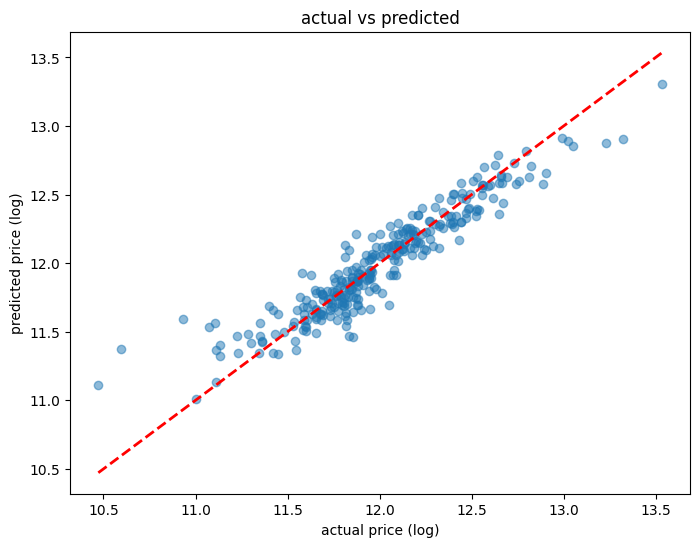

In [8]:
# actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel('actual price (log)')
plt.ylabel('predicted price (log)')
plt.title('actual vs predicted')
plt.show()

In [9]:
# see which features matter most
coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients.sort_values(ascending=False).head(10))

OverallQual     0.085631
GarageCars      0.073756
BsmtFullBath    0.072417
Fireplaces      0.049132
OverallCond     0.044196
FullBath        0.033150
HalfBath        0.021931
BsmtHalfBath    0.016210
TotRmsAbvGrd    0.014395
YearBuilt       0.002962
dtype: float64


In [10]:
print(coefficients['GrLivArea'])

0.00014949108906272618
